# Bäume (Trees)
Ein Baum ist eine Menge von Knoten (Nodes), die Eltern-Kind-Beziehungen haben. 
- Jeder Knoten kann mehrere Kinder haben, aber höchstens einen Elternknoten. 
- Es gibt genau einen Knoten ohne Eltern, den sogenannten Wurzelknoten (Root).
- Knoten ohne Kinder werden Blätter (Leaves) genannt.

Ein Spezialfall eines Baumes ist der binäre Baum, bei dem jeder Knoten entweder null, oder zwei Kinder hat. (Manchmal ist auch ein Kind erlaubt.)

Um Bäume in Python zu realisieren, braucht man eine Klasse für die Knoten. Diese Klasse enthält:
- Daten, die der Knoten speichern soll
- Eine Liste von Kindknoten
- evtl. Methoden, um Kinder hinzuzufügen und zu entfernen
- evtl. den Elternknoten

In [29]:
class Node:
    def __init__(self, value):
        self.value = value
        self.children = []
        self.parent = None
        
    def add_child(self, child_node):
        child_node.parent = self
        self.children.append(child_node)

Manchmal ist es auch sinnvoll, eine eigene Klasse für den Baum zu definieren, die den Wurzelknoten und andere Baum-Methoden enthält.
- `get_ancestors(node)`: Gibt alle Vorfahren eines Knotens zurück.
- `plot()`: Visualisiert den Baum mit `matplotlib`

Alternativ kann man Bäume auch mit verschachtelten Listen oder Dictionaries darstellen, aber das ist oft unübersichtlich und schwer zu handhaben.

In [30]:
class Tree:
    def __init__(self,value):
        self.root = Node(value)        
    
    def get_ancestors(self, node):
        ancestors = []
        current = node
        while current.parent is not None:
            ancestors.append(current.parent)
            current = current.parent
        return ancestors

    def plot(self):        
        import matplotlib.pyplot as plt
        def _plot_node(node, x, y, dx, ax, depth=0):
            ax.text(x, y, str(node.value), ha='center', va='center', bbox=dict(boxstyle="circle", fc="w"))
            if node.children:
                next_y = y - 1
                width = dx * (len(node.children) - 1)
                for i, child in enumerate(node.children):
                    next_x = x - width/2 + i*dx
                    ax.plot([x, next_x], [y, next_y], 'k-')
                    _plot_node(child, next_x, next_y, dx/2, ax, depth+1)

        fig, ax = plt.subplots(figsize=(5,3))
        ax.axis('off')
        _plot_node(self.root, x=0, y=0, dx=2, ax=ax)
        plt.show()

Wir erstellen einen kleinen binären Baum

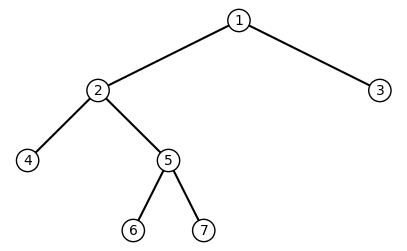

Vorfahren von Knoten 6: [5, 2, 1]


In [31]:
tr = Tree(1)
n1 = Node(2)
n2 = Node(3)
tr.root.add_child(n1)
tr.root.add_child(n2)
n3 = Node(4)
n4 = Node(5)
n1.add_child(n3)
n1.add_child(n4)
n5 = Node(6)
n6 = Node(7)
n4.add_child(n5)
n4.add_child(n6)
# Visualisierung des Baums
tr.plot()
# Vorfahren von Knoten 6 ausgeben
print("Vorfahren von Knoten 6:", [node.value for node in tr.get_ancestors(n5)])



## Beispiel: Min-Max Algorithmus 
Bäume werden oft verwendet um Entscheidungsprozesse zu modellieren. 
Als Beispiel betrachten wir das Spiel Tic-Tac-Toe:
- Zwei Spieler (X und O) setzen abwechselnd ihre Zeichen auf ein 3x3 Gitter.
- Ziel ist es, drei eigene Zeichen in einer Reihe (horizontal, vertikal oder diagonal) zu haben.
- Das Spiel endet, wenn ein Spieler gewinnt oder alle Felder besetzt sind (Unentschieden).

Wir speichern den Spielzustand in einem Baum:
- Der Root-Knoten repräsentiert den Anfangszustand (leeres Gitter).
- Jeder Knoten hat Kinder, die die möglichen Spielzüge darstellen.
    - Im Unterschied zu oben verwenden wir hier ein Dictionary, um die Kinder zu speichern, damit wir den Zug der vom aktuellen Knoten zum Kind führt als Schlüssel speichern können.
- Jeder Knoten speichert, welcher Spieler am Zug ist (`player`),
- und den aktuellen Spielzustand (`game_state`)

In [41]:
import copy
class TreeNode:
    node_count  = 1
    def __init__(self, value):       
        self.value = value
        self.player = None
        self.game_state = None
        self.children = dict()
    def add_child(self, child_node, move):
        self.children[move] = child_node
        TreeNode.node_count += 1
    def determine_winner(self):
        lines = self.game_state + [list(col) for col in zip(*self.game_state)] + [[self.game_state[i][i] for i in range(3)], [self.game_state[i][2-i] for i in range(3)]]
        for line in lines:
            if line[0] is not None and all(cell == line[0] for cell in line):                
                self.value = 1 if line[0] == 'X' else -1                
                return
        if all(cell is not None for row in self.game_state for cell in row):
            self.value = 0
            return
        self.value = None
    def update(self):
        if self.value is not None:
            return self.value
        if self.player == 'X':
            self.value = max(child.update() for child in self.children.values())
        else:
            self.value = min(child.update() for child in self.children.values())
        return self.value
    def __str__(self):
        state = "  1 2 3\n"
        for i, row in enumerate(self.game_state):
            state += f"{i+1} " + "|".join(cell if cell is not None else " " for cell in row) + "\n"
        return state
    

Die Klasse hat 3 neue Methoden: `determine_winner()`, `update()` und `__str__()`.

__`determine_winner()`__ überprüft, ob ein Spieler im aktuellen Zug (Node) gewonnen hat oder ob das Spiel unentschieden ist.
- Dazu werden zuerst alle möglichen Linien (horizontal, vertikal, diagonal) des Gitters in einer Liste gespeichert.
    - `self.game_state` ist bereits eine Liste der horizontalen Linien.
    - Die vertikalen Linien werden mit einer List Comprehension und `zip` erstellt.
        - `zip(*self.game_state)` entspricht `zip(self.game_state[0], self.game_state[1], self.game_state[2])` und erzeugt Tupel der vertikalen Linien.
    - Die diagonalen Linien werden manuell mit List-Comprehensions erstellt.
- Dann wird überprüft, ob eine der Linien nur aus 'X's oder nur aus 'O's besteht.
    - Wenn ja, wird in `self.value` 1 (für 'X' gewinnt) oder -1 (für 'O' gewinnt) gespeichert
- Fall kein Gewinner ermittelt werden kann und alle Felder belegt sind, ist das Spiel unentschieden und `self.value` wird auf 0 gesetzt.
- Ansonsten wird `self.value` auf `None` gesetzt, was bedeutet, dass das Spiel noch nicht beendet ist.

__`__str__()`__ gibt eine String-Darstellung des Spielzustands zurück, die das Gitter in einer lesbaren Form darstellt.

### Min-Max Algorithmus in `update()`
Die Methode `update()` implementiert den Min-Max Algorithmus, der in Zwei-Personenen-Spielen verwendet wird, um den optimalen Zug zu bestimmen.
- Wenn der Knoten bereits einen Wert (`self.value`) hat, wird dieser zurückgegeben.
- Wenn der Spieler am Zug 'X' ist, wird der maximale Wert der Kindknoten berechnet (da 'X' versucht zu gewinnen, also `1` zu erreichen).
- Wenn der Spieler am Zug 'O' ist, wird der minimale Wert der Kindknoten berechnet (da 'O' versucht zu gewinnen, also `-1` zu erreichen).
- Der berechnete Wert wird in `self.value` gespeichert und zurückgegeben.

Der Min-Max Algorithmus bewertet rekursiv alle möglichen Spielzüge und deren Ergebnisse.
- Somit kann der beste Zug für den aktuellen Spieler bestimmt werden, indem man den Kindknoten mit dem besten Wert auswählt.
- Min-Max liefert immer eine optimale Strategie für beide Spieler
- Min-Max muss den gesamten Spielbaum aufbauen und durchsuchen, was bei komplexeren Spielen sehr rechenintensiv sein kann.
    - Oft kann man durch abscheiden (pruning) Teile des Baumes ignorieren, die keinen Einfluss auf das Endergebnis haben.
    - Unsere Implementierung von Tic-Tac-Toe benötigt 549946 Knoten
        - Es kommen Spielzustände mehrfach vor, da unterschiedliche Zugfolgen zum gleichen Ergebnis führen können
    - "4 Gewinnt" (oder "Connect Four") hat 4,531,985,219,092 verschiedene Spielzustände
    - "Schach" hat ca. $10^{120}$ mögliche Spielverläufe (die Zahl der Atome im beobachtbaren Universum wird auf ca. $10^{80}$ geschätzt)

Der folgende Code generiert den gesamten Spielbaum für Tic-Tac-Toe und berechnet die optimalen Züge mit Min-Max.
Der Wert des Wurzelknotens is besonders interessant
- Ein Wert von `1` bedeutet, dass der Spieler, der zuerst zieht (X), mit optimaler Strategie gewinnen kann.
- Ein Wert von `-1` bedeutet, dass der zweite Spieler (O) mit optimaler Strategie gewinnen kann.
- Ein Wert von `0` bedeutet, dass das Spiel bei optimaler Strategie beider Spieler unentschieden endet (Das ist bei Tic-Tac-Toe der Fall).

Bemerkung: 
- Bei "4 Gewinnt" kann der erste Spieler mit optimaler Strategie immer gewinnen (egal was der zweite Spieler macht).
- Bei "Schach" ist diese Frage noch offen (es wird vermutet, dass bei optimaler Strategie beider Spieler das Spiel unentschieden endet).



In [59]:
root = TreeNode(None)
root.game_state = [[None, None, None], [None, None, None], [None, None, None]]
root.player = 'X'
def generate_children(curr_node):
    curr_node.determine_winner()
    if curr_node.value is not None:
        return
    for i, row in enumerate(curr_node.game_state):
        for j, cell in enumerate(row):
            if cell is None:                
                child = TreeNode(None)
                child.game_state = copy.deepcopy(curr_node.game_state)
                child.game_state[i][j] = curr_node.player
                child.player = 'O' if curr_node.player == 'X' else 'X'                
                curr_node.add_child(child,(i,j))
                generate_children(child)
        

generate_children(root)
print(f"Anzahl der Knoten im Baum: {TreeNode.node_count}")
root_value = root.update()
print(f"Wert des Wurzelknotens (optimaler Spielausgang für X): {root_value}")

Anzahl der Knoten im Baum: 1099891
Wert des Wurzelknotens (optimaler Spielausgang für X): 0


### Beispiel: Tic-Tac-Toe Computer
Wir können den Spielbaum nun verwenden, um einen einfachen Tic-Tac-Toe Computer zu bauen, der immer den optimalen Zug macht.
- User (`X`) gibt den gewünschten Zug ein
- Computer sucht den entsprechenden Kindknoten im Baum und wählt den besten Antwort-Zug (falls mehrere möglich sind, wird zufällig gewählt)
- `print(...., flush=True)` sorgt dafür, dass die Ausgabe sofort angezeigt wird (kann sonst zu Konflikten mit der Eingabeaufforderung führen)

In [61]:
import random
def play_game(root):
    print(root, flush=True)
    x,y = map(int,input("Enter row and col: ").split(" "))
    x -= 1
    y -= 1
    if root.children:
        if (x,y) in root.children:
            root = root.children[(x,y)]
        else:
            print("Invalid move!", flush=True)
            play_game(root)
            return
        if root.children:
            best_value = min(child.value for child in root.children.values())
            best_moves = [child for child in root.children.values() if child.value == best_value]
            play_game(random.choice(best_moves))
        else:
            print("You win!" if root.value == 1 else "It's a draw!" if root.value == 0 else "Computer wins!", flush=True)
    else:
        print("You win!" if root.value == 1 else "It's a draw!" if root.value == 0 else "Computer wins!", flush=True)
        return        
    
play_game(root)    

  1 2 3
1  | | 
2  | | 
3  | | 

  1 2 3
1  | | 
2  |X| 
3  | |O

  1 2 3
1  | |X
2  |X| 
3 O| |O

  1 2 3
1  |O|X
2  |X| 
3 O|X|O

  1 2 3
1  |O|X
2 X|X|O
3 O|X|O

It's a draw!


Da der Computer immer perfekt spielt, kann ein User nie gewinnen. Um eine Chance zu haben, muss man von einer unfairen Anfangsposition starten.

In [53]:
start = root.children[(1,1)].children[(0,1)]
play_game(start)

  1 2 3
1  |O| 
2  |X| 
3  | | 

  1 2 3
1  |O|X
2  |X| 
3 O| | 

  1 2 3
1  |O|X
2 O|X| 
3 O| |X

You win!


## Beispiel: Mesh-Refinement
- Mesh-Refinement ist eine Technik in der numerischen Mathematik, um die Genauigkeit von Simulationen zu verbessern.
- Dabei wird ein Gitter (Mesh) in kleinere Zellen unterteilt, um Bereiche mit hoher Variabilität genauer zu erfassen.
- Dies wird oft in der Finite-Elemente-Methode (FEM) verwendet, um komplexe geometrische Formen und physikalische Phänomene zu modellieren.
    - Mehr dazu in den Vorlesungen: __Numerik partieller Differentialgleichungen: (in)stationäre Probleme__

Wer erstellen zuerst eine Klasse `Element`, die ein einzelnes Dreieck im Gitter repräsentiert.
- Die Klasse speichert die Eckpunkte des Dreiecks
- Die Klasse speichert die Kinder und Eltern des Elements
- `marked` gibt an, ob das Element zur Verfeinerung markiert ist
- `refine()` teilt das Dreieck in vier kleinere ähnliche Dreiecke auf (Red-Refinement)
    - Dabei werden die Mittelpunkte der Seiten berechnet und als neue Eckpunkte verwendet
    - Die Kinder werden erstellt und die Eltern-Kind-Beziehungen werden gesetzt


In [54]:
import numpy as np
class Element:
    def __init__(self, vertices):
        self.vertices = vertices  # 2x3 np.array of vertex coordinates in clockwise order
        self.children = []        # Sub-elements after refinement
        self.parent = None
        self.marked = False  # For adaptive refinement
    def center(self):
        return np.mean(self.vertices, axis=1)
    def refine(self):
        midpoints = 0.5*(self.vertices[:,[0,1,2]] + self.vertices[:,[1,2,0]])
        c1 = Element(np.block([midpoints[:,2:3], midpoints[:,1:2], self.vertices[:,2:3]]))
        c2 = Element(np.block([self.vertices[:,0:1],midpoints[:,0:1], midpoints[:,2:3]]))
        c3 = Element(np.block([midpoints[:,0:1],self.vertices[:,1:2], midpoints[:,1:2]]))
        c4 = Element(np.block([midpoints[:,2:3], midpoints[:,0:1], midpoints[:,1:2]]))
        self.children = [c1,c2,c3,c4]
        for child in self.children:
            child.parent = self
        return self.children
    


Wir implementieren dann eine Klasse `Mesh`, die das gesamte Gitter verwaltet.
- Die Klasse speichert eine Liste von Elementen
    - Diese Elemente sind die Blätter des Verfeinerungsbaums
- `refine_marked()` verfeinert alle markierten Elemente und aktualisiert die Liste der Blätter (`self.elements`)
- `coarsen()` macht eine Verfeinerung rückgängig, ersetzt also vier Kinder durch ihr Eltern-Element (wenn möglich)
- `plot()` visualisiert das Gitter mit `matplotlib`

In [55]:
import matplotlib.pyplot as plt
class Mesh:
    def __init__(self, elements):
        self.elements = elements  # List of Element objects
    def refine_marked(self):
        new_elements = [e for e in self.elements if not e.marked]
        for elem in [e for e in self.elements if e.marked]:
            new_elements.extend(elem.refine())
        self.elements = new_elements
    def coarsen(self):
        to_remove = set() 
        for elem in self.elements:
            if elem.parent and all(child in self.elements for child in elem.parent.children):
                to_remove.add(elem)                
                self.elements.append(elem.parent)
        self.elements = [e for e in self.elements if e not in to_remove]
    def plot(self):       
        for elem in self.elements:
            plt.plot(elem.vertices[0,[0,1,2,0]], elem.vertices[1,[0,1,2,0]], 'b-')
        plt.gca().set_aspect('equal')

Wir erstellen ein einfaches Beispielgitter und führen einige Verfeinerungen und eine Vergröberung durch.

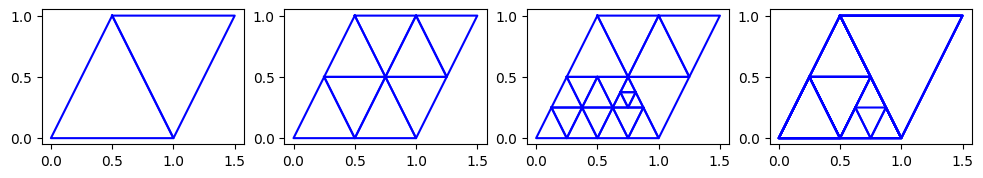

In [56]:
# Initiales Dreieck
T0 = Element(np.array([[0.5,1,0],[1,0,0]]))
T1 = Element(np.array([[0.5,1.5,1],[1, 1,0]]))

# Mesh
mesh = Mesh([T0,T1])
plt.subplots(1,4,figsize=(12,3))
plt.subplot(1,4,1)
mesh.plot()
mesh.elements[0].marked = True
mesh.elements[1].marked = True
mesh.refine_marked()
plt.subplot(1,4,2)
mesh.plot()
mesh.elements[2].marked = True
mesh.elements[3].marked = True
mesh.refine_marked()
mesh.elements[0].marked = True
mesh.elements[7].marked = True
mesh.refine_marked()
plt.subplot(1,4,3)
mesh.plot()

mesh.coarsen()
plt.subplot(1,4,4)
mesh.plot()
plt.show()

### Anwendung: 2D Approximation
Eine einfache aber wichtige Anwendung ist die Approximation von Funktionen auf einem Mesh. Dazu definieren wir eine Klasse `PWLinear`, die von `Mesh` erbt und eine stückweise lineare Approximation implementiert.
- `approximate(f)` berechnet den Wert einer Funktion `f` an jeder Ecke des Elements und speichert diesen Wert in `self.values`
- `mark_elements(f, tol)` markiert alle Elemente, bei denen der Unterschied zwischen dem linear interpoliertem Wert im Schwerpunkt des Elements und der tatsächlichen Funktion größer als `tol` ist.
- `plot()` visualisiert das Gitter und die approximierte Funktion in einem 3D-Plot mit `matplotlib`
- `refine_marked()` wird neu definiert
    - Zuerst wird die Methode der Elternklasse aufgerufen, um die markierten Elemente zu verfeinern
    - Dann wird die Liste `self.values` auf die neue Anzahl der Elemente angepasst und mit 0 initialisiert

In [57]:
class PWLinear(Mesh):
    def __init__(self, elements):
        super().__init__(elements)
        self.values = np.zeros((len(elements),3))  # Nodal values
    def refine_marked(self):
        super().refine_marked()
        self.values = np.zeros((len(self.elements),3))  # Reset values after refinement
    def approximate(self, f):
        for i, elem in enumerate(self.elements):
            for j in range(3):
                self.values[i,j] = f(elem.vertices[0,j], elem.vertices[1,j]) 
    def mark_elements(self, f, tol):
        for i, elem in enumerate(self.elements):
            c = elem.center()
            if np.abs(f(c[0],c[1]) - np.mean(self.values[i,:])) > tol:
                elem.marked = True                    
    def plot(self):
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        for i, elem in enumerate(self.elements):
            verts = elem.vertices
            ax.plot_trisurf(verts[0], verts[1], self.values[i,:], color=plt.cm.viridis(np.mean(self.values[i,:])), alpha=0.5, edgecolor='k')        
        plt.show()

Wir testen die Klasse an der Funktion $f(x,y) = \cos(\pi x) y^4$.
- Wir beobachten, dass nach mehrern Verfeinerungen die Approximation immer genauer wird.
- In Bereichen, wo die Funktion $f$ sich nicht stark ändert, bleiben die Elemente groß, während in Bereichen mit hoher Variabilität die Elemente kleiner werden.

After 3 adaptive refinements:


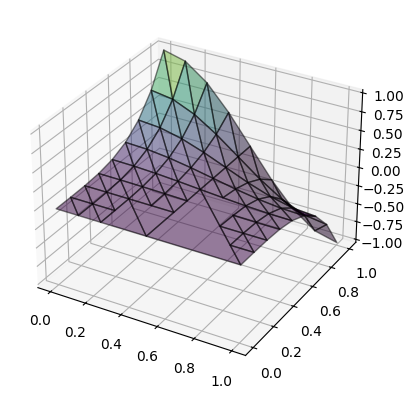

After 5 adaptive refinements:


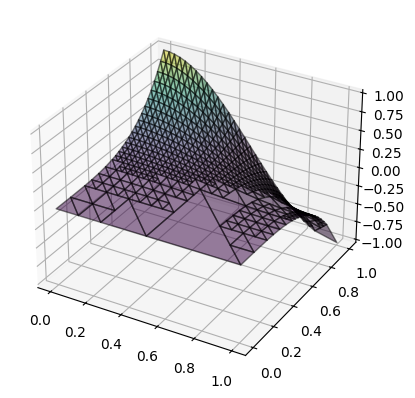

In [58]:
mesh = PWLinear([Element(np.array([[0,1,0],[1,0,0]])), Element(np.array([[0,1,1],[1,1,0]]))])

f = lambda x,y: np.cos(np.pi*x)*y**4
mesh.approximate(f)
for _ in range(3):
    mesh.mark_elements(f, tol=0.001)
    mesh.refine_marked()
    mesh.approximate(f)
print("After 3 adaptive refinements:")
mesh.plot()
for _ in range(2):
    mesh.mark_elements(f, tol=0.001)
    mesh.refine_marked()
    mesh.approximate(f)
print("After 5 adaptive refinements:")
mesh.plot()

Die originale Funktion sieht so aus:

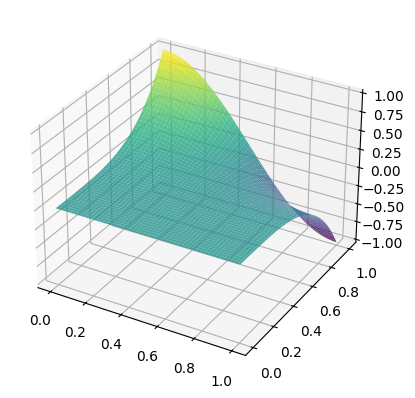

In [12]:
X, Y = np.meshgrid(np.linspace(0,1,100), np.linspace(0,1,100))
Z = np.cos(np.pi*X)*Y**4
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
plt.show()